# SquadCredit - Credit Score Model
### LightGBM + SHAP Pipeline

This notebook builds the SquadCredit credit scoring model from scratch.

**What this notebook does, step by step:**
1. Load the synthetic trader dataset
2. Explore the data so we understand what we're working with
3. Train a LightGBM model to predict loan repayment
4. Evaluate how good the model is
5. Use SHAP to explain *why* each trader gets the score they get
6. Convert the model output into a 0-1000 credit score
7. Score three example traders and show their explanations

**The four signal categories and weights:**
| Category | Weight | What it measures |
|---|---|---|
| Cash Flow | 50% | Volume, regularity, trend, average payment size |
| Customer | 25% | Unique customers, repeat ratio, growth |
| Behaviour | 15% | Savings discipline, weekday trading consistency |
| Trust | 10% | Association verified, prior repayment, neighbour vouch |


### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make charts look clean
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#F8F9FA"
plt.rcParams["font.family"] = "sans-serif"

print("All libraries loaded successfully.")

c:\SquadCredit Model\squad_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries loaded successfully.


### Load the Data

Each row is one synthetic trader.
Each column is one feature or the repayment outcome.

**`repaid` column:**
- `1` = this trader repaid their loan on time
- `0` = this trader defaulted

The model will learn to predict this column from the 12 feature columns.
Once trained, it outputs a probability (e.g. 0.82) which we scale to a credit score (820).


In [2]:
df = pd.read_csv(r"C:\SquadCredit Model\squadcredit_synthetic_data.csv")

print(f"Dataset shape: {df.shape}  →  {df.shape[0]} traders, {df.shape[1]} columns")
print(f"\nRepayment breakdown:")
print(f"  Repaid (1):    {df['repaid'].sum()}  ({df['repaid'].mean():.1%})")
print(f"  Defaulted (0): {(df['repaid']==0).sum()}  ({1-df['repaid'].mean():.1%})")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (500, 13)  →  500 traders, 13 columns

Repayment breakdown:
  Repaid (1):    360  (72.0%)
  Defaulted (0): 140  (28.0%)

First 5 rows:


,total_inflow_30d,inflow_regularity,inflow_trend,avg_payment_size,unique_customers_30d,repeat_customer_ratio,customer_growth_rate,savings_retention_rate,weekday_trading_ratio,association_verified,prior_repayment_score,neighbour_attested,repaid
0,84658.90,0.8551,0.1571,2911.24,21,0.5655,0.3523,0.2462,0.6964,1,0.9163,1,1
1,42104.47,0.7362,-0.2306,5276.39,46,0.7296,0.0833,0.2839,0.8394,1,0.0000,0,1
2,99953.20,0.5058,0.2294,4747.87,39,0.7495,0.4926,0.2323,0.6155,0,0.0000,0,1
3,261799.14,0.4999,-0.1397,45421.02,32,0.8170,0.6189,0.2790,0.8284,0,0.0000,0,1
4,37889.58,0.5445,-0.0291,5512.76,39,0.7248,0.6478,0.2627,0.6791,1,0.0000,0,1


### Understand the Data

Before training anything, let's see what the numbers look like.
This is called **exploratory data analysis (EDA)**.


In [3]:
# Basic statistics for every column
print("Summary statistics:")
df.describe().round(2)

Summary statistics:


,total_inflow_30d,inflow_regularity,inflow_trend,avg_payment_size,unique_customers_30d,repeat_customer_ratio,customer_growth_rate,savings_retention_rate,weekday_trading_ratio,association_verified,prior_repayment_score,neighbour_attested,repaid
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,93736.83,0.58,0.05,6065.88,30.26,0.58,0.40,0.28,0.72,0.55,0.30,0.37,0.72
std,193154.29,0.17,0.17,8337.80,11.06,0.21,0.20,0.16,0.15,0.50,0.38,0.48,0.45
min,1386.59,0.14,-0.43,272.59,8.00,0.09,0.02,0.01,0.14,0.00,0.00,0.00,0.00
25%,22689.62,0.47,-0.08,2108.37,22.00,0.43,0.25,0.16,0.63,0.00,0.00,0.00,0.00
50%,49715.74,0.58,0.05,3844.56,29.00,0.58,0.38,0.26,0.74,1.00,0.00,0.00,1.00
75%,98762.82,0.70,0.16,7510.14,36.00,0.74,0.55,0.38,0.83,1.00,0.74,1.00,1.00
max,3395646.20,0.96,0.60,137807.62,85.00,0.99,0.95,0.80,1.00,1.00,0.99,1.00,1.00


In [4]:
# Check for missing values — there should be none
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None. All columns complete.")

Missing values per column:
None. All columns complete.


### Visualise: Do repaid traders look different from defaulters?

This is the most important chart before training.
If the distributions overlap completely, the model will struggle.
If they separate clearly, the model will work well.


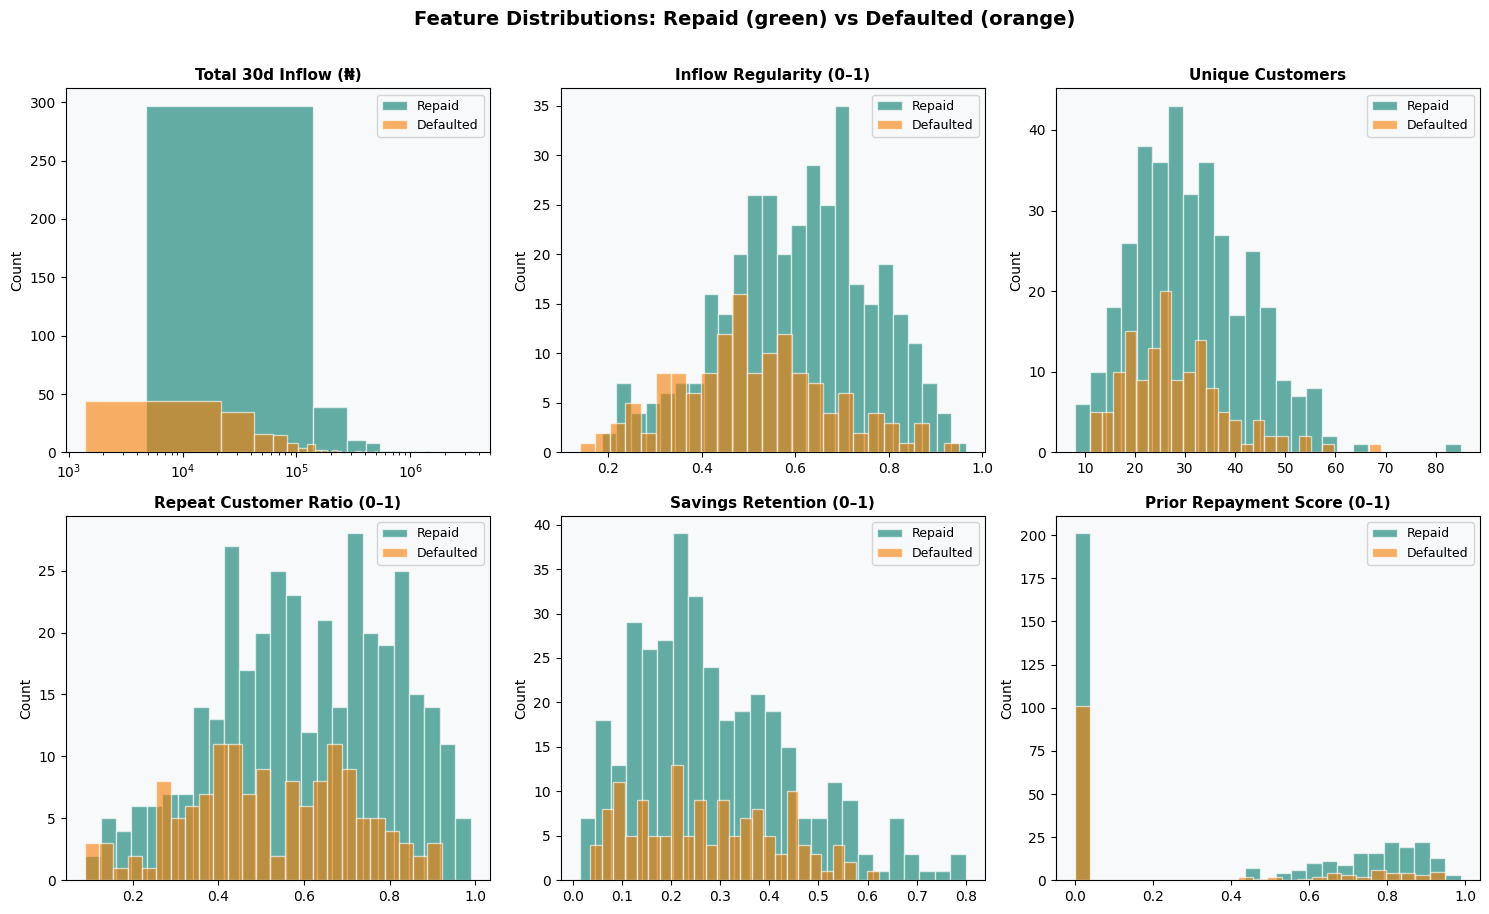

Saved → eda_feature_distributions.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Feature Distributions: Repaid (green) vs Defaulted (orange)",
             fontsize=14, fontweight="bold", y=1.01)

features_to_plot = [
    ("total_inflow_30d",       "Total 30d Inflow (₦)",       True),
    ("inflow_regularity",      "Inflow Regularity (0–1)",     False),
    ("unique_customers_30d",   "Unique Customers",            False),
    ("repeat_customer_ratio",  "Repeat Customer Ratio (0–1)", False),
    ("savings_retention_rate", "Savings Retention (0–1)",     False),
    ("prior_repayment_score",  "Prior Repayment Score (0–1)", False),
]

for ax, (col, label, log_scale) in zip(axes.flat, features_to_plot):
    repaid_vals   = df[df["repaid"] == 1][col]
    default_vals  = df[df["repaid"] == 0][col]

    ax.hist(repaid_vals,  bins=25, alpha=0.6, color="#00796B", label="Repaid",    edgecolor="white")
    ax.hist(default_vals, bins=25, alpha=0.6, color="#F57C00", label="Defaulted", edgecolor="white")

    if log_scale:
        ax.set_xscale("log")

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → eda_feature_distributions.png")

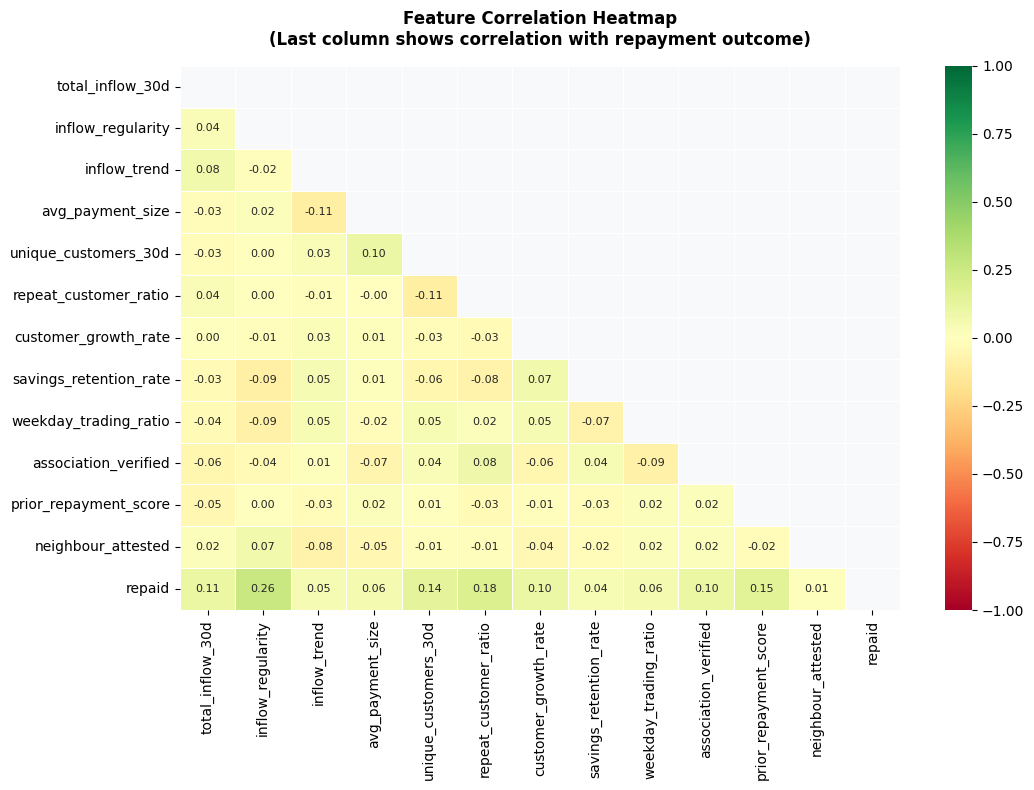

Saved → eda_correlation_heatmap.png

Correlation with repayment outcome (sorted):
inflow_regularity         0.259
repeat_customer_ratio     0.181
prior_repayment_score     0.152
unique_customers_30d      0.136
total_inflow_30d          0.106
association_verified      0.105
customer_growth_rate      0.095
avg_payment_size          0.059
weekday_trading_ratio     0.058
inflow_trend              0.048
savings_retention_rate    0.044
neighbour_attested        0.014


In [6]:
# Correlation heatmap — do features relate to repayment?
# Values close to 1 or -1 mean strong relationship with repayment.

fig, ax = plt.subplots(figsize=(11, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (duplicate)

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, annot_kws={"size": 8}
)

ax.set_title("Feature Correlation Heatmap\n(Last column shows correlation with repayment outcome)",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → eda_correlation_heatmap.png")
print("\nCorrelation with repayment outcome (sorted):")
print(corr["repaid"].drop("repaid").sort_values(ascending=False).round(3).to_string())

### Prepare Data for Training

We separate:
- **X** = the 12 feature columns (inputs to the model)
- **y** = the `repaid` column (what the model learns to predict)

Then we split into:
- **Training set (80%)** — the model learns from this
- **Test set (20%)** — we use this to measure how well it learned

The model never sees the test set during training. It's our honest evaluation.


In [7]:
# Define feature columns grouped by category — for reference
CASH_FLOW_FEATURES = [
    "total_inflow_30d",
    "inflow_regularity",
    "inflow_trend",
    "avg_payment_size",
]

CUSTOMER_FEATURES = [
    "unique_customers_30d",
    "repeat_customer_ratio",
    "customer_growth_rate",
]

BEHAVIOUR_FEATURES = [
    "savings_retention_rate",
    "weekday_trading_ratio",
]

TRUST_FEATURES = [
    "association_verified",
    "prior_repayment_score",
    "neighbour_attested",
]

ALL_FEATURES = CASH_FLOW_FEATURES + CUSTOMER_FEATURES + BEHAVIOUR_FEATURES + TRUST_FEATURES

X = df[ALL_FEATURES]
y = df["repaid"]

# Split: 80% train, 20% test
# stratify=y ensures both splits have the same repayment ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {len(X_train)} traders  ({y_train.mean():.1%} repayment rate)")
print(f"Test set:      {len(X_test)} traders  ({y_test.mean():.1%} repayment rate)")
print(f"Total features: {len(ALL_FEATURES)}")
print(f"\nFeature columns: {ALL_FEATURES}")

Training set:  400 traders  (72.0% repayment rate)
Test set:      100 traders  (72.0% repayment rate)
Total features: 12

Feature columns: ['total_inflow_30d', 'inflow_regularity', 'inflow_trend', 'avg_payment_size', 'unique_customers_30d', 'repeat_customer_ratio', 'customer_growth_rate', 'savings_retention_rate', 'weekday_trading_ratio', 'association_verified', 'prior_repayment_score', 'neighbour_attested']


### Train the LightGBM Model

LightGBM is a **gradient-boosted decision tree** model.

In [8]:
model = lgb.LGBMClassifier(
    objective="binary",       # binary: repaid (1) or defaulted (0)
    n_estimators=300,         # maximum number of trees to build
    learning_rate=0.05,       # how much each tree corrects the previous one
    max_depth=4,              # keep trees shallow — prevents overfitting on 500 rows
    num_leaves=15,            # max branches per tree
    min_child_samples=10,     # each leaf needs at least 10 traders (prevents overfitting)
    subsample=0.8,            # use 80% of data per tree — adds healthy randomness
    colsample_bytree=0.8,     # use 80% of features per tree
    class_weight="balanced",  # adjusts for 72%/28% repaid/default imbalance
    random_state=42,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        # stops early if test performance stops improving — prevents overfitting
    ]
)

print(f"Training complete.")
print(f"Trees built: {model.best_iteration_}  (early stopping kicked in)")

Training complete.
Trees built: 87  (early stopping kicked in)


### Model Evaluation

**AUC (Area Under the Curve)** is the standard metric for credit scoring models.

- **0.5** = the model is useless - just random guessing
- **0.7** = good for a thin-file model with no credit bureau data
- **0.8+** = strong model
- **1.0** = perfect (never happens in real life)

In [9]:
# Get predictions on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of repaying
y_pred       = model.predict(X_test)               # binary: 1 or 0

auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print(f"  AUC Score: {auc:.4f}")
print("=" * 50)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Defaulted (0)", "Repaid (1)"]))

  AUC Score: 0.7584

Classification Report:
               precision    recall  f1-score   support

Defaulted (0)       0.55      0.61      0.58        28
   Repaid (1)       0.84      0.81      0.82        72

     accuracy                           0.75       100
    macro avg       0.69      0.71      0.70       100
 weighted avg       0.76      0.75      0.75       100



How to read this:
  Top-left:     Correctly predicted Defaulted (True Negatives)
  Top-right:    Predicted Repaid but actually Defaulted (False Positives — costly!)
  Bottom-left:  Predicted Defaulted but actually Repaid (False Negatives — lost revenue)
  Bottom-right: Correctly predicted Repaid (True Positives)


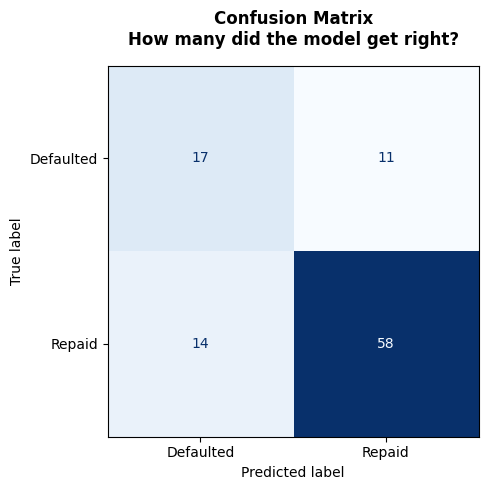

In [10]:
# Confusion matrix — shows how many the model got right and wrong
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Defaulted", "Repaid"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)

ax.set_title("Confusion Matrix\nHow many did the model get right?",
             fontsize=12, fontweight="bold", pad=15)

# Annotation to help read the matrix
print("How to read this:")
print("  Top-left:     Correctly predicted Defaulted (True Negatives)")
print("  Top-right:    Predicted Repaid but actually Defaulted (False Positives — costly!)")
print("  Bottom-left:  Predicted Defaulted but actually Repaid (False Negatives — lost revenue)")
print("  Bottom-right: Correctly predicted Repaid (True Positives)")

plt.tight_layout()
plt.savefig("model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### Converting Probability to Credit Score (0–1000)

The model outputs a probability between 0.0 and 1.0.
We scale this to 0–1000 to match what the trader sees in the SquadCredit app.

- Probability 0.90 → Score ~880
- Probability 0.60 → Score ~620
- Probability 0.30 → Score ~340

We also assign a **tier** based on the score:

| Score | Tier | Max Loan |
|---|---|---|
| 0–499 | T0 Trial | ₦5K – ₦15K |
| 500–574 | T1 Starter | ₦15K – ₦50K |
| 575–624 | T2 Builder | ₦50K – ₦150K |
| 625–674 | T3 Established | ₦150K – ₦500K |
| 675–724 | T4 Growth | ₦500K – ₦1.5M |
| 725–774 | T5 Scale | ₦1.5M – ₦5M |
| 775+ | T6 Anchor | ₦5M – ₦25M |


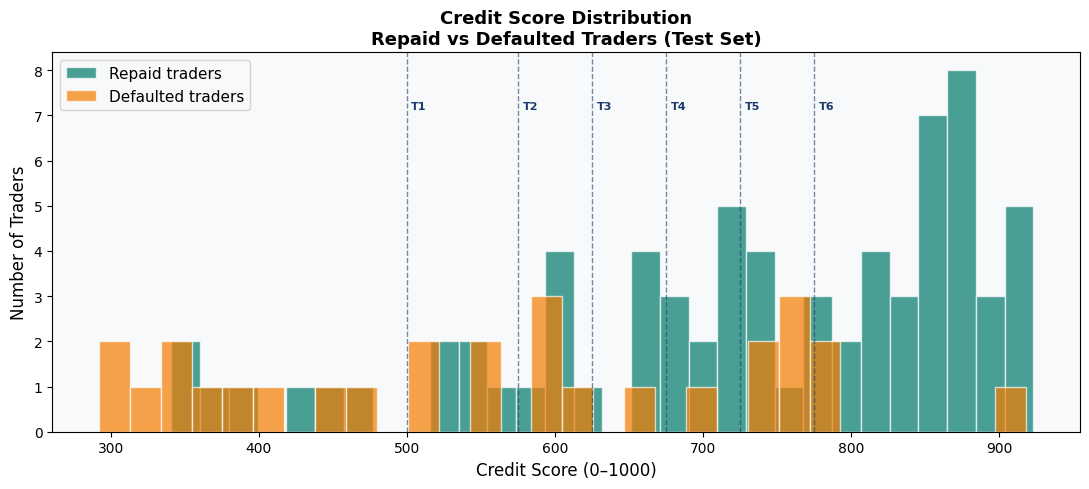

Average score — Repaid traders:    729
Average score — Defaulted traders: 564


In [11]:
def probability_to_score(prob):
    """Convert repayment probability (0–1) to credit score (0–1000)."""
    # We use a slight curve so scores spread realistically across the range.
    # Probability 0.0  →  score ~100  (never 0 — some uncertainty always remains)
    # Probability 0.5  →  score ~500
    # Probability 1.0  →  score ~950  (never 1000 — same reason)
    score = 100 + (prob ** 0.75) * 850
    return int(np.clip(score, 100, 950))


def get_tier(score):
    """Return the credit tier for a given score."""
    if score >= 775: return "T6 Anchor    — up to ₦25M"
    if score >= 725: return "T5 Scale     — up to ₦5M"
    if score >= 675: return "T4 Growth    — up to ₦1.5M"
    if score >= 625: return "T3 Established — up to ₦500K"
    if score >= 575: return "T2 Builder   — up to ₦150K"
    if score >= 500: return "T1 Starter   — up to ₦50K"
    return   "T0 Trial     — up to ₦15K"


# Show score distribution across all test traders
test_scores = pd.Series(y_pred_proba).apply(probability_to_score)

fig, ax = plt.subplots(figsize=(11, 5))

repaid_idx  = y_test.values == 1
default_idx = y_test.values == 0

ax.hist(test_scores[repaid_idx],  bins=30, alpha=0.7, color="#00796B",
        label="Repaid traders",    edgecolor="white")
ax.hist(test_scores[default_idx], bins=30, alpha=0.7, color="#F57C00",
        label="Defaulted traders", edgecolor="white")

# Add tier threshold lines
for threshold, label in [(500, "T1"), (575, "T2"), (625, "T3"), (675, "T4"), (725, "T5"), (775, "T6")]:
    ax.axvline(x=threshold, color="#1B3A6B", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(threshold + 3, ax.get_ylim()[1] * 0.85, label,
            color="#1B3A6B", fontsize=8, fontweight="bold")

ax.set_xlabel("Credit Score (0–1000)", fontsize=12)
ax.set_ylabel("Number of Traders",     fontsize=12)
ax.set_title("Credit Score Distribution\nRepaid vs Defaulted Traders (Test Set)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("model_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average score — Repaid traders:    {test_scores[repaid_idx].mean():.0f}")
print(f"Average score — Defaulted traders: {test_scores[default_idx].mean():.0f}")

### SHAP Explanations

**SHAP = SHapley Additive exPlanations**

In plain English: for each trader, SHAP asks
*"how much did each feature push the score up or down?"*

Answers why loans are approved or denied. 

In [12]:
print("Computing SHAP values...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# LightGBM binary classification returns SHAP for both classes.
# We want class 1 (repaid = positive outcome).
if isinstance(shap_values, list):
    shap_repaid = shap_values[1]
else:
    shap_repaid = shap_values

print(f"SHAP values computed for {len(X_test)} test traders.")
print(f"Shape: {shap_repaid.shape}  →  (traders × features)")

Computing SHAP values...
SHAP values computed for 100 test traders.
Shape: (100, 12)  →  (traders × features)


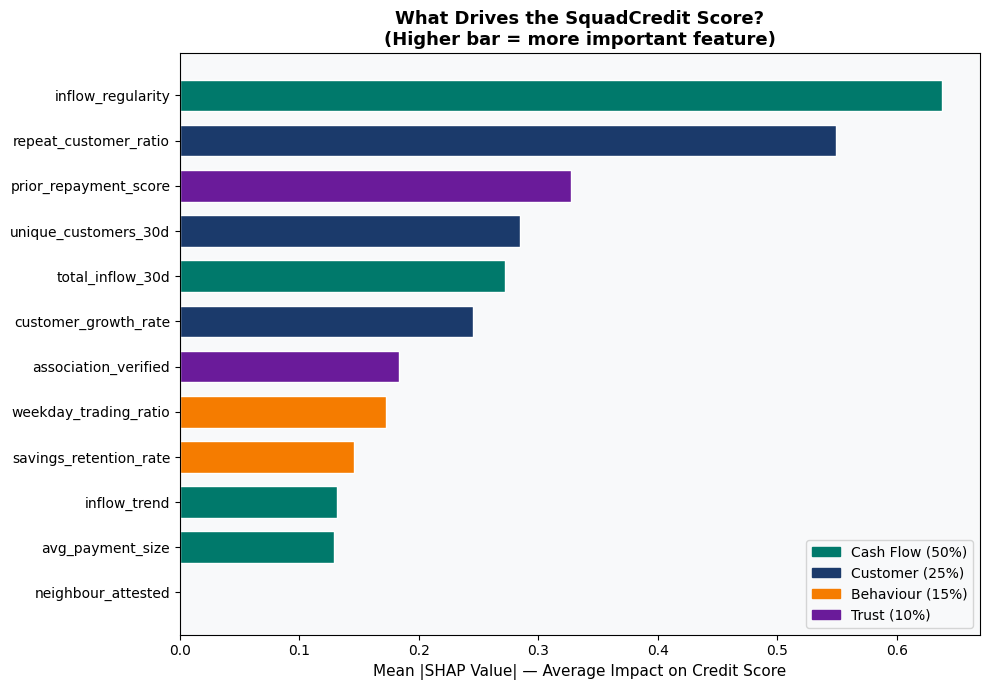

Saved → shap_feature_importance.png


In [13]:
# ── Chart 1: Feature Importance by SHAP ─────────────────────────
# Which features matter most OVERALL across all traders?

mean_abs_shap = np.abs(shap_repaid).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": mean_abs_shap,
}).sort_values("importance", ascending=True)

# Colour bars by signal category
color_map = {
    "total_inflow_30d":       "#00796B",
    "inflow_regularity":      "#00796B",
    "inflow_trend":           "#00796B",
    "avg_payment_size":       "#00796B",
    "unique_customers_30d":   "#1B3A6B",
    "repeat_customer_ratio":  "#1B3A6B",
    "customer_growth_rate":   "#1B3A6B",
    "savings_retention_rate": "#F57C00",
    "weekday_trading_ratio":  "#F57C00",
    "association_verified":   "#6A1B9A",
    "prior_repayment_score":  "#6A1B9A",
    "neighbour_attested":     "#6A1B9A",
}
colors = [color_map[f] for f in importance_df["feature"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df["feature"], importance_df["importance"],
        color=colors, edgecolor="white", height=0.7)

legend_handles = [
    mpatches.Patch(color="#00796B", label="Cash Flow (50%)"),
    mpatches.Patch(color="#1B3A6B", label="Customer (25%)"),
    mpatches.Patch(color="#F57C00", label="Behaviour (15%)"),
    mpatches.Patch(color="#6A1B9A", label="Trust (10%)"),
]
ax.legend(handles=legend_handles, fontsize=10)
ax.set_xlabel("Mean |SHAP Value| — Average Impact on Credit Score", fontsize=11)
ax.set_title("What Drives the SquadCredit Score?\n(Higher bar = more important feature)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → shap_feature_importance.png")

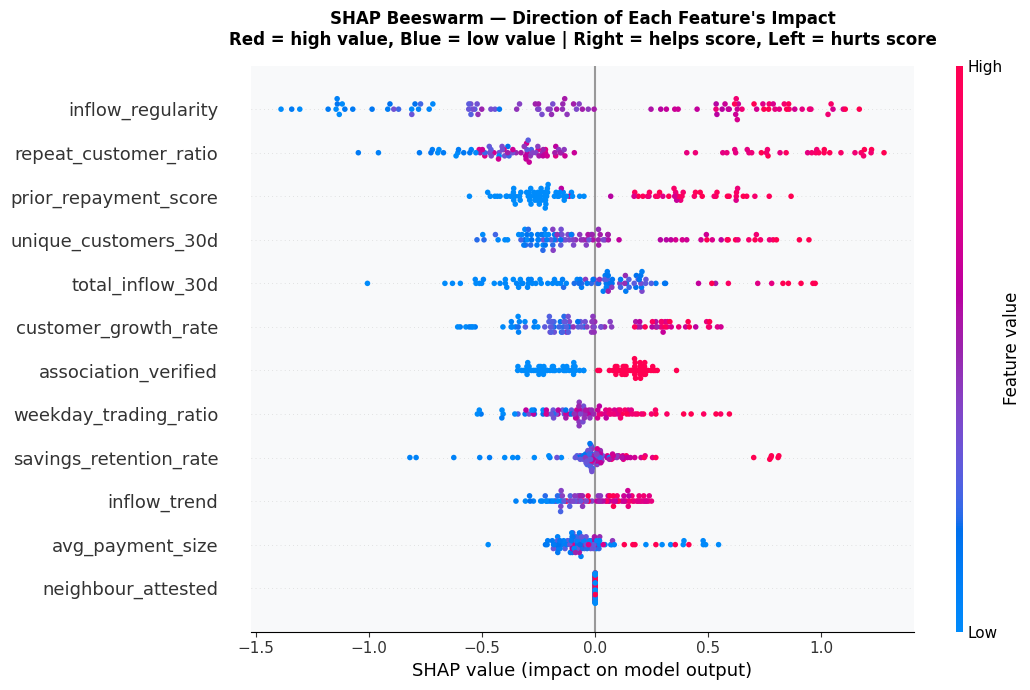

Saved → shap_beeswarm.png

How to read this chart:
  Each dot = one trader.
  Red dots on the RIGHT = high inflow_regularity helps repayment. Makes sense.
  Blue dots on the LEFT = low savings_retention hurts repayment. Makes sense.


In [14]:
# ── Chart 2: SHAP Beeswarm ───────────────────────────────────────
# Shows DIRECTION — does high inflow_regularity push score UP or DOWN?
# Red dots = high feature value. Blue = low feature value.
# Dots on the right = pushed the score UP (good for repayment).
# Dots on the left  = pushed the score DOWN (bad for repayment).

plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_repaid, X_test,
    feature_names=ALL_FEATURES,
    show=False, plot_size=(11, 7)
)
plt.title("SHAP Beeswarm — Direction of Each Feature's Impact\n"
          "Red = high value, Blue = low value | Right = helps score, Left = hurts score",
          fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → shap_beeswarm.png")
print("\nHow to read this chart:")
print("  Each dot = one trader.")
print("  Red dots on the RIGHT = high inflow_regularity helps repayment. Makes sense.")
print("  Blue dots on the LEFT = low savings_retention hurts repayment. Makes sense.")

### Function for Scoring an Individual Trader

This is the function your app calls.

**Input:** one trader's feature values (from their Squad webhook data)
**Output:** credit score, tier, and plain-English + Pidgin explanation


In [15]:
def score_trader(features: dict) -> dict:
    """
    Score one trader and explain the result.

    Parameters
    ----------
    features : dict
        One trader's feature values. Keys must match ALL_FEATURES list.

    Returns
    -------
    dict containing:
        credit_score  : int   (0–1000)
        tier          : str
        repay_prob    : float (raw model output)
        top_factors   : list of str (plain English explanation)
        pidgin        : list of str (Pidgin explanation)
    """

    input_df = pd.DataFrame([features])[ALL_FEATURES]

    # Get repayment probability from the model
    prob  = model.predict_proba(input_df)[0][1]
    score = probability_to_score(prob)
    tier  = get_tier(score)

    # Get SHAP values for this specific trader
    sv = explainer.shap_values(input_df)
    trader_shap = (sv[1] if isinstance(sv, list) else sv)[0]

    shap_series = pd.Series(trader_shap, index=ALL_FEATURES).sort_values(ascending=False)

    # Top 3 factors helping the score
    top_positive = shap_series[shap_series > 0].head(3)
    # Top 3 factors hurting the score
    top_negative = shap_series[shap_series < 0].tail(3)

    # Explanation templates — English and Pidgin
    templates = {
        "total_inflow_30d":       ("Your total monthly inflows are strong",        "Your monthly money wey dey enter dey plenty"),
        "inflow_regularity":      ("Your payments come in very consistently",       "Your payments dey come regular regular"),
        "inflow_trend":           ("Your business inflows are growing",             "Your business money dey increase"),
        "avg_payment_size":       ("Your average transaction size is healthy",      "Your average payment dey fine"),
        "unique_customers_30d":   ("You have a diverse customer base",              "You get plenty different customers"),
        "repeat_customer_ratio":  ("Your customers keep coming back to you",        "Your customers dey return to you"),
        "customer_growth_rate":   ("You are consistently gaining new customers",    "New customers dey always come your way"),
        "savings_retention_rate": ("You keep a healthy float in your account",      "You dey save well well"),
        "weekday_trading_ratio":  ("You trade consistently on weekdays",            "You dey trade every market day"),
        "association_verified":   ("Your market association has verified you",      "Your market union don verify you"),
        "prior_repayment_score":  ("You have a strong loan repayment history",      "Your repayment history strong"),
        "neighbour_attested":     ("A fellow trader has vouched for you",            "One trader wey dey near you don vouch for you"),
    }
    neg_templates = {
        "total_inflow_30d":       ("Your total inflows need to grow more",          "Your monthly money wey dey enter still small"),
        "inflow_regularity":      ("Your payments are coming in irregularly",       "Your payments no dey come steady"),
        "inflow_trend":           ("Your inflows have been declining recently",     "Your money wey dey enter don begin reduce"),
        "avg_payment_size":       ("Your average transaction size is very small",   "Your average payment still too small"),
        "unique_customers_30d":   ("Most payments come from very few people",       "Na only few people dey pay you"),
        "repeat_customer_ratio":  ("You have few returning customers so far",       "Not many customers dey return to you yet"),
        "customer_growth_rate":   ("Your customer base is not growing yet",         "New customers no dey come enough"),
        "savings_retention_rate": ("You spend almost everything you receive",       "You dey spend everything wey enter"),
        "weekday_trading_ratio":  ("Your trading pattern is inconsistent",          "Your trading pattern no steady"),
        "association_verified":   ("You are not yet association-verified",          "Your market union never verify you yet"),
        "prior_repayment_score":  ("No prior repayment history yet",                "You never borrow before so we no get history"),
        "neighbour_attested":     ("No neighbour attestation yet",                  "No trader don vouch for you yet"),
    }

    factors_en = []
    factors_pid = []

    for feat, val in top_positive.items():
        en, pid = templates.get(feat, (feat, feat))
        factors_en.append(f"✓  {en}")
        factors_pid.append(f"✓  {pid}")

    for feat, val in top_negative.items():
        en, pid = neg_templates.get(feat, (feat, feat))
        factors_en.append(f"✗  {en}")
        factors_pid.append(f"✗  {pid}")

    return {
        "credit_score": score,
        "tier":         tier,
        "repay_prob":   round(float(prob), 4),
        "top_factors":  factors_en,
        "pidgin":       factors_pid,
    }


print("score_trader() function ready.")
print("Usage: result = score_trader(trader_feature_dict)")

score_trader() function ready.
Usage: result = score_trader(trader_feature_dict)


### Scoring Three Example Traders

These three traders represent the range of SquadCredit's customer base:
- **Sade** - established, strong trader (Balogun Market)
- **Emeka** - developing trader, decent history (Computer Village)
- **Hauwa** - brand new, just onboarded (Kantin Kwari, Kano)


In [16]:
traders = {

    "Sade — Fabric Seller, Balogun Market": {
        # Strong cash flow — active trader, ₦180K/month
        "total_inflow_30d":       180_000,
        "inflow_regularity":      0.88,
        "inflow_trend":           0.18,
        "avg_payment_size":       4_500,
        # Good customer diversity
        "unique_customers_30d":   65,
        "repeat_customer_ratio":  0.74,
        "customer_growth_rate":   0.48,
        # Disciplined behaviour
        "savings_retention_rate": 0.32,
        "weekday_trading_ratio":  0.92,
        # Strong trust signals
        "association_verified":   1,
        "prior_repayment_score":  0.91,
        "neighbour_attested":     1,
    },

    "Emeka — Phone Accessories, Computer Village": {
        # Moderate cash flow
        "total_inflow_30d":       52_000,
        "inflow_regularity":      0.55,
        "inflow_trend":           0.06,
        "avg_payment_size":       2_200,
        # Smaller customer base
        "unique_customers_30d":   20,
        "repeat_customer_ratio":  0.48,
        "customer_growth_rate":   0.28,
        # Some savings discipline
        "savings_retention_rate": 0.14,
        "weekday_trading_ratio":  0.70,
        # Partially verified
        "association_verified":   1,
        "prior_repayment_score":  0.0,   # first-time borrower
        "neighbour_attested":     0,
    },

    "Hauwa — Textile Seller, Kantin Kwari (New)": {
        # Low history — just onboarded
        "total_inflow_30d":       14_000,
        "inflow_regularity":      0.28,
        "inflow_trend":          -0.04,
        "avg_payment_size":         900,
        # Very few customers so far
        "unique_customers_30d":    7,
        "repeat_customer_ratio":  0.22,
        "customer_growth_rate":   0.12,
        # Minimal savings
        "savings_retention_rate": 0.06,
        "weekday_trading_ratio":  0.50,
        # No trust signals yet
        "association_verified":   0,
        "prior_repayment_score":  0.0,
        "neighbour_attested":     0,
    },
}


for name, features in traders.items():
    result = score_trader(features)
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(f"  Credit Score : {result['credit_score']} / 1000")
    print(f"  Tier         : {result['tier']}")
    print(f"  Repay Prob   : {result['repay_prob']:.1%}")
    print(f"\n  What's driving this score:")
    for line in result["top_factors"]:
        print(f"    {line}")
    print(f"\n  In Pidgin:")
    for line in result["pidgin"]:
        print(f"    {line}")
    print()

  Sade — Fabric Seller, Balogun Market
  Credit Score : 939 / 1000
  Tier         : T6 Anchor    — up to ₦25M
  Repay Prob   : 98.4%

  What's driving this score:
    ✓  You have a diverse customer base
    ✓  Your payments come in very consistently
    ✓  Your total monthly inflows are strong

  In Pidgin:
    ✓  You get plenty different customers
    ✓  Your payments dey come regular regular
    ✓  Your monthly money wey dey enter dey plenty

  Emeka — Phone Accessories, Computer Village
  Credit Score : 554 / 1000
  Tier         : T1 Starter   — up to ₦50K
  Repay Prob   : 43.4%

  What's driving this score:
    ✓  Your market association has verified you
    ✓  Your total monthly inflows are strong
    ✗  No prior repayment history yet
    ✗  Your payments are coming in irregularly
    ✗  You have few returning customers so far

  In Pidgin:
    ✓  Your market union don verify you
    ✓  Your monthly money wey dey enter dey plenty
    ✗  You never borrow before so we no get history

### SHAP Waterfall Chart for Sade

This chart shows exactly how each feature pushed Sade's score up or down.



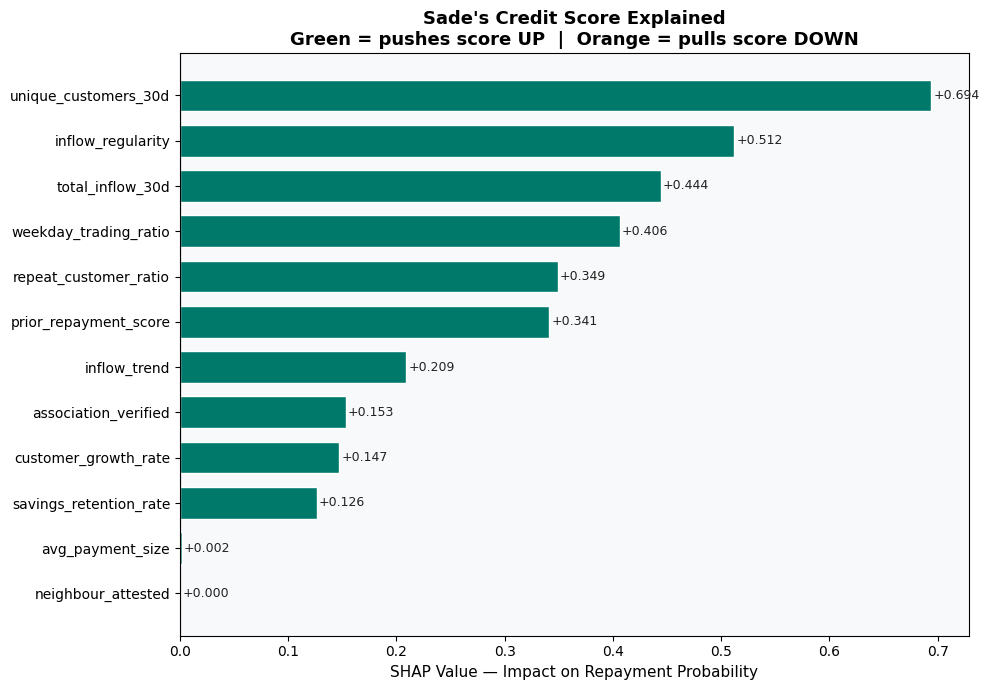

Saved → shap_sade_waterfall.png

This chart is what you show when a judge asks: 'How does the AI explain itself?'


In [ ]:
# Score Sade and show her SHAP waterfall
sade_features = traders["Sade — Fabric Seller, Balogun Market"]
sade_df = pd.DataFrame([sade_features])[ALL_FEATURES]

sv = explainer.shap_values(sade_df)
sade_shap = (sv[1] if isinstance(sv, list) else sv)[0]

# Build waterfall data
waterfall_df = pd.DataFrame({
    "feature":  ALL_FEATURES,
    "shap_val": sade_shap,
}).sort_values("shap_val", ascending=True)

colors = ["#F57C00" if v < 0 else "#00796B" for v in waterfall_df["shap_val"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(waterfall_df["feature"], waterfall_df["shap_val"],
               color=colors, edgecolor="white", height=0.7)

ax.axvline(x=0, color="#1B3A6B", linewidth=1.5)
ax.set_xlabel("SHAP Value — Impact on Repayment Probability", fontsize=11)
ax.set_title("Sade's Credit Score Explained\n"
             "Green = pushes score UP  |  Orange = pulls score DOWN",
             fontsize=13, fontweight="bold")

# Add value labels on bars
for bar, val in zip(bars, waterfall_df["shap_val"]):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.3f}",
        va="center", ha="left" if val >= 0 else "right",
        fontsize=9, color="#212121"
    )

plt.tight_layout()
plt.savefig("shap_sade_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → shap_sade_waterfall.png")

In [ ]:
#save the model for future use
import joblib

joblib.dump(model, "squadcredit_model.pkl")
print("Model saved → squadcredit_model.pkl")

In [ ]:
#create a function that takes a trader's features as input transforms them into the required features for the model
#  and returns their credit score, tier, and explanation in both English and Pidgin.

def end_to_end_credit_scoring(trader_features: dict) -> dict:
    """
    End-to-end function to score a trader and provide explanations.

    Parameters
    ----------
    trader_features : dict
        A dictionary containing the raw features of the trader.

    Returns
    -------
    dict containing:
        credit_score  : int   (0–1000)
        tier          : str
        repay_prob    : float (raw model output)
        top_factors   : list of str (plain English explanation)
        pidgin        : list of str (Pidgin explanation)
    """
    # Step 1: Transform raw features into model input format
    # For this example, we assume the input is already in the correct format.
    # In a real application, you would include any necessary preprocessing here.
    
    # Step 2: Score the trader using the previously defined function
    result = score_trader(trader_features)
    
    return result